# Imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import os
import numpy as np
import cartopy.crs as ccrs
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
from dask.diagnostics.progress import ProgressBar
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
import xclim


In [2]:
def get_refhistfut_quick(variable, folder = 'era5-cmip6_exp_ens'):
    hist = xr.open_zarr(f'/data/ecmwf_eib/data/{folder}/{variable}/{variable}_hist_allsources.zarr')[variable]
    fut = xr.open_zarr(f'/data/ecmwf_eib/data/{folder}/{variable}/{variable}_fut_allsources.zarr')[variable]
    return hist, fut

In [3]:
import sys
from pathlib import Path

# Resolve path from ./notebook up into ./indicator_delta_scaling/src
src_path = Path('../src').resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))


%load_ext autoreload
%autoreload 2
from xids import IDS
from xids import indicators

# Testing IDS module

## TXx

In [75]:
tasmax_hist, tasmax_fut = get_refhistfut_quick('tasmax', folder = 'era5-cmip6_exp_ens',)

tasmax_ref = tasmax_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tasmax_model = xr.concat([tasmax_hist.sel(source='simu'), tasmax_fut.sel(source='simu')], dim='time')
#tasmax_model

In [78]:

# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute TXX using xclim indicator function
txx_ref, txx_hist, txx_fut, txx_delta = ids.compute_indicator(
    reference_data = tasmax_ref,
    model_data = tasmax_model,
    indicator_func=xclim.indices.tx_max, 
    freq = 'YS',
    delta_mode='+',
    compute = True,
    short_name = 'txx',
    long_name = 'Maximum daily maximum temperature',
    units = 'ºC',
)


[########################################] | 100% Completed | 408.64 ms
[########################################] | 100% Completed | 302.66 ms
[########################################] | 100% Completed | 1.78 ss
[########################################] | 100% Completed | 1.65 ss


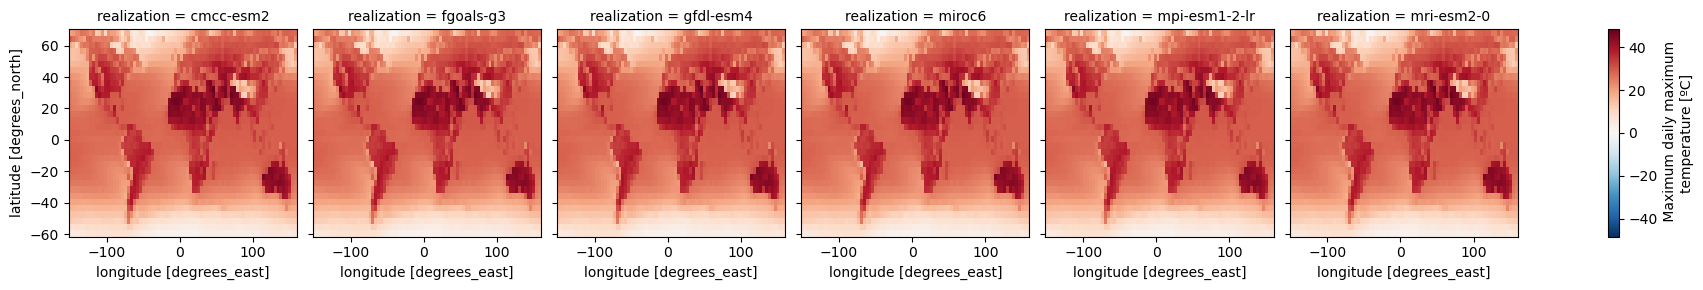

In [79]:
(txx_hist).plot(col='realization')

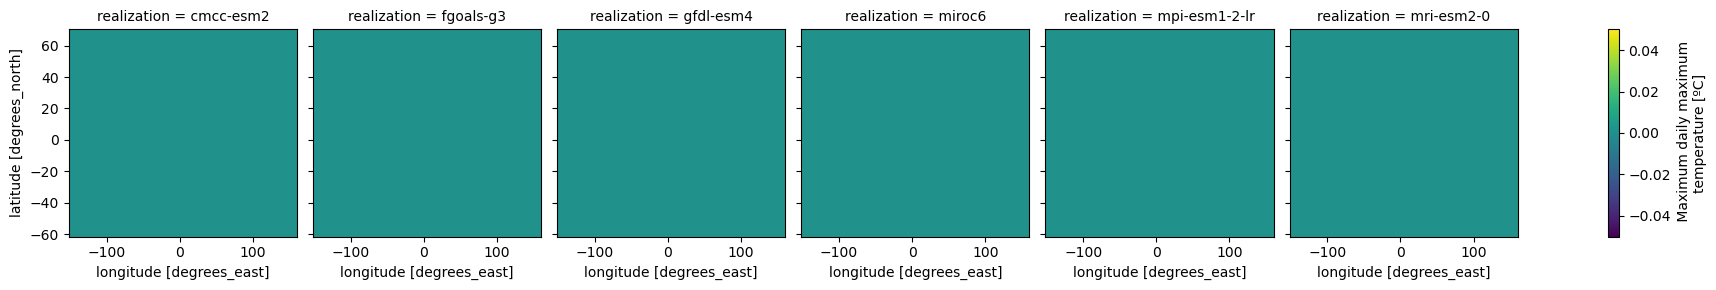

In [80]:
(txx_hist-txx_ref).plot(col='realization')

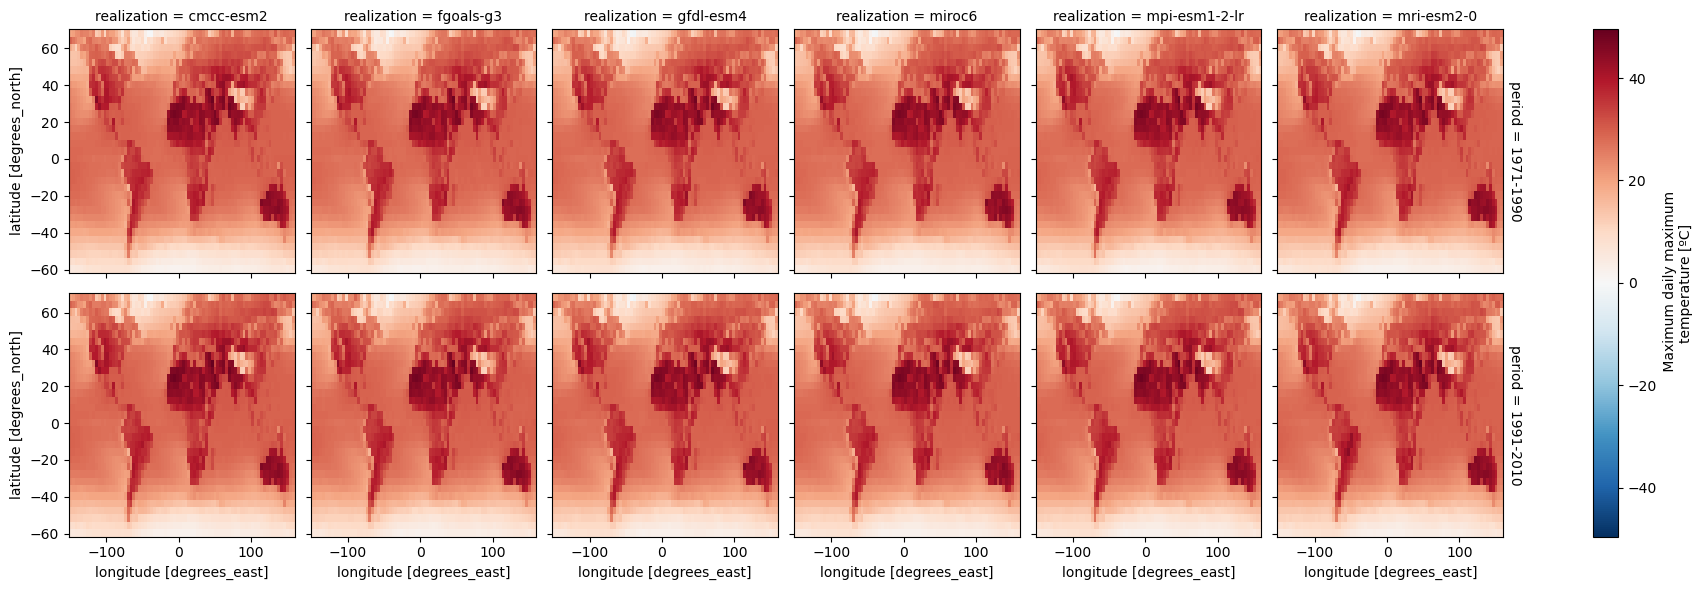

In [81]:
(txx_fut).plot(col='realization', row = 'period')

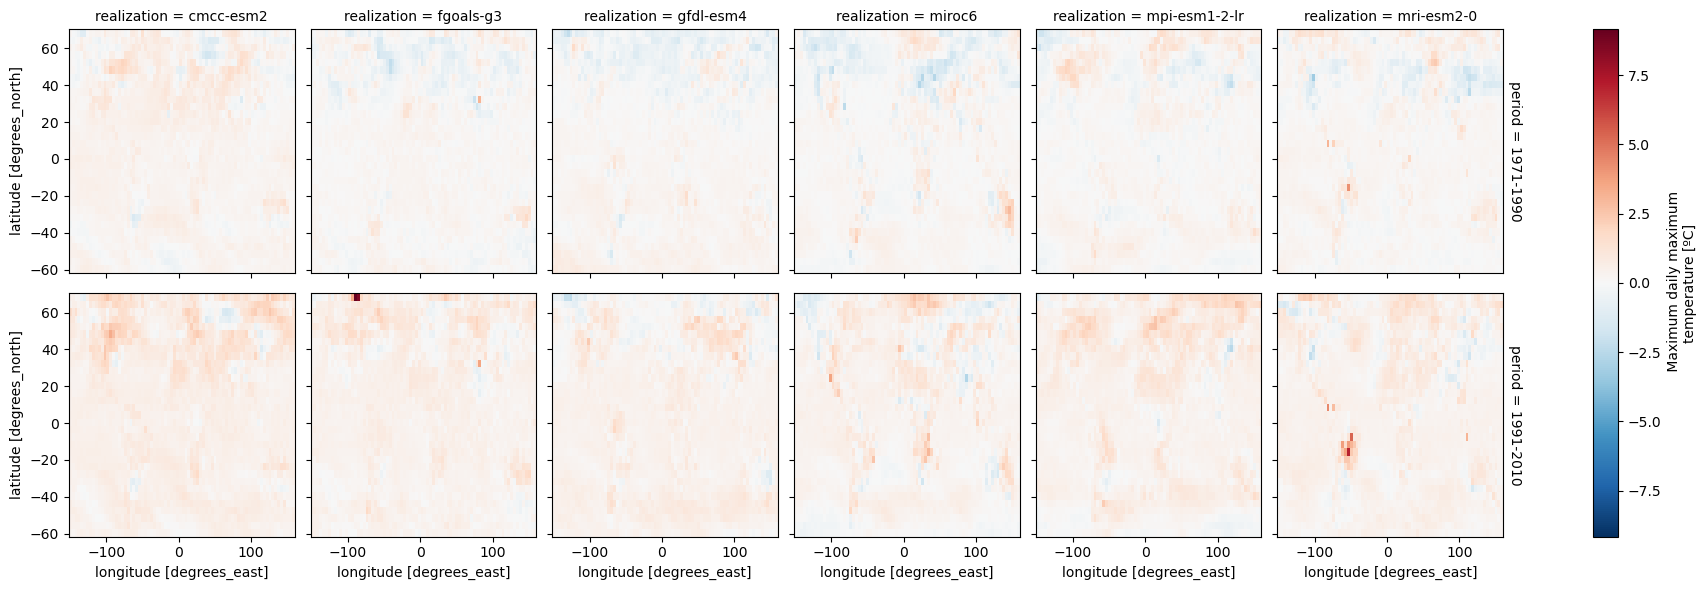

In [82]:
(txx_fut-txx_hist.isel(period=0)).plot(col='realization', row='period')

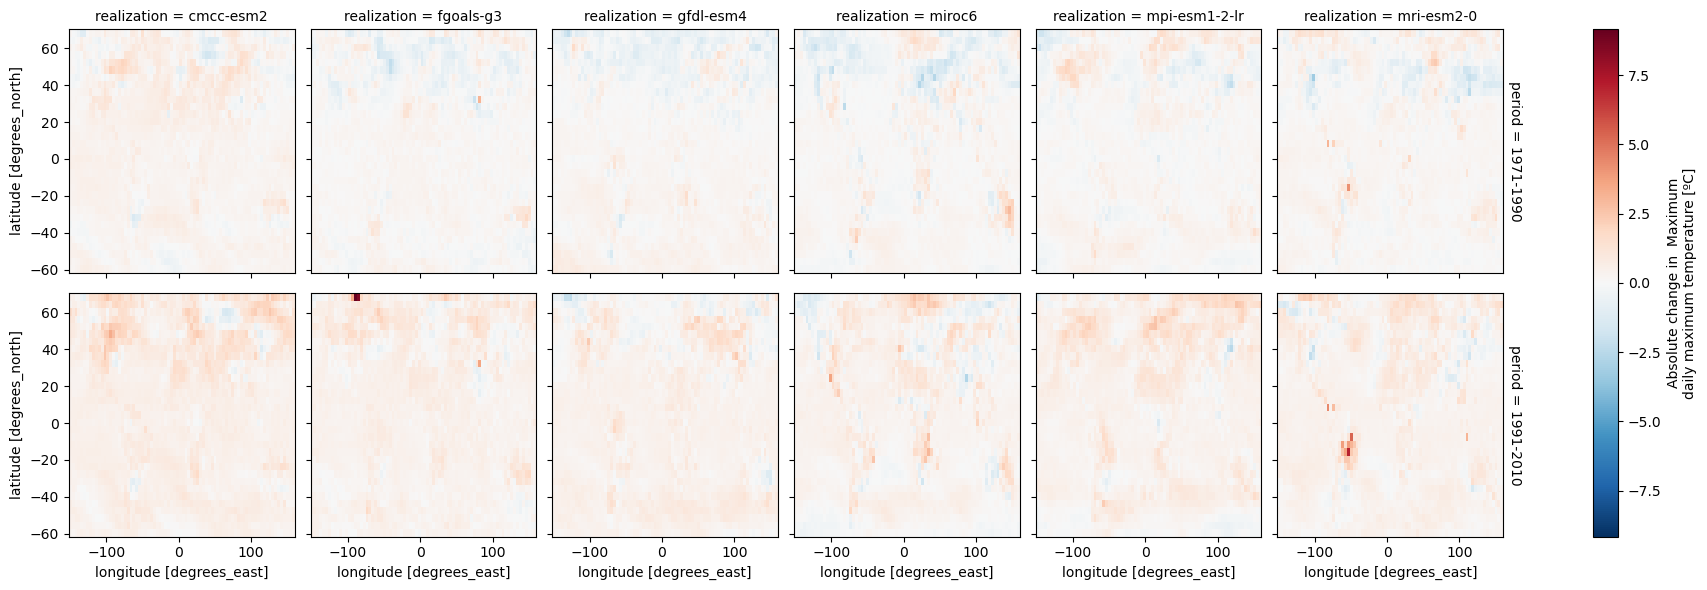

In [83]:
(txx_delta).plot(col='realization', row='period')

## RX1day

In [18]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time')
#pr_model

In [19]:


# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute RX1day using xclim indicator function
rx1day_ref, rx1day_hist, rx1day_fut, rx1day_delta = ids.compute_indicator(
    reference_data = pr_ref,
    model_data = pr_model,
    indicator_func=xclim.indices.max_1day_precipitation_amount, 
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'rx1day',
    long_name = 'Maximum daily precipitation amount',
    units = 'mm',
    delta_factor_percentage = True,
)


[########################################] | 100% Completed | 202.19 ms
[########################################] | 100% Completed | 202.67 ms
[########################################] | 100% Completed | 711.49 ms
[########################################] | 100% Completed | 508.02 ms
[########################################] | 100% Completed | 511.05 ms
[########################################] | 100% Completed | 511.57 ms


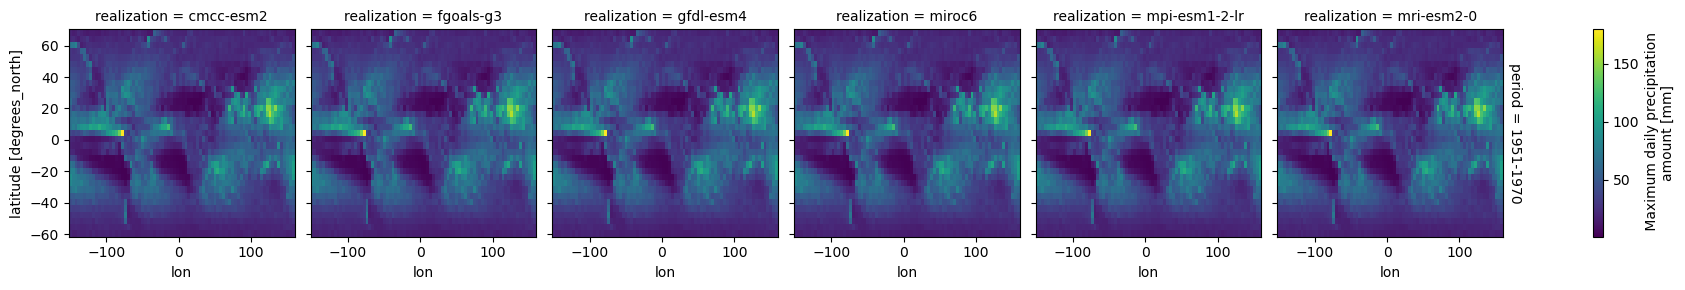

In [20]:
rx1day_hist.plot(col='realization', row = 'period')

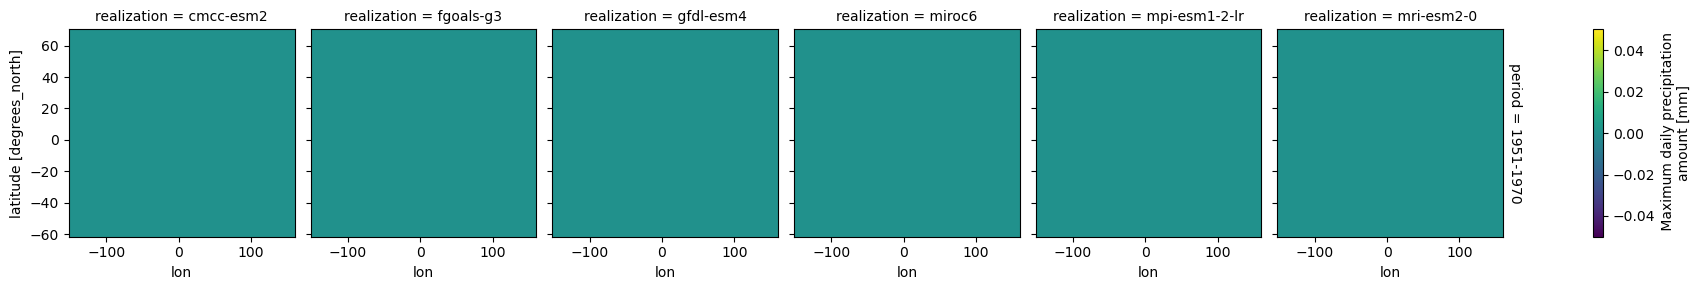

In [102]:
(rx1day_hist-rx1day_ref).plot(col='realization', row = 'period')

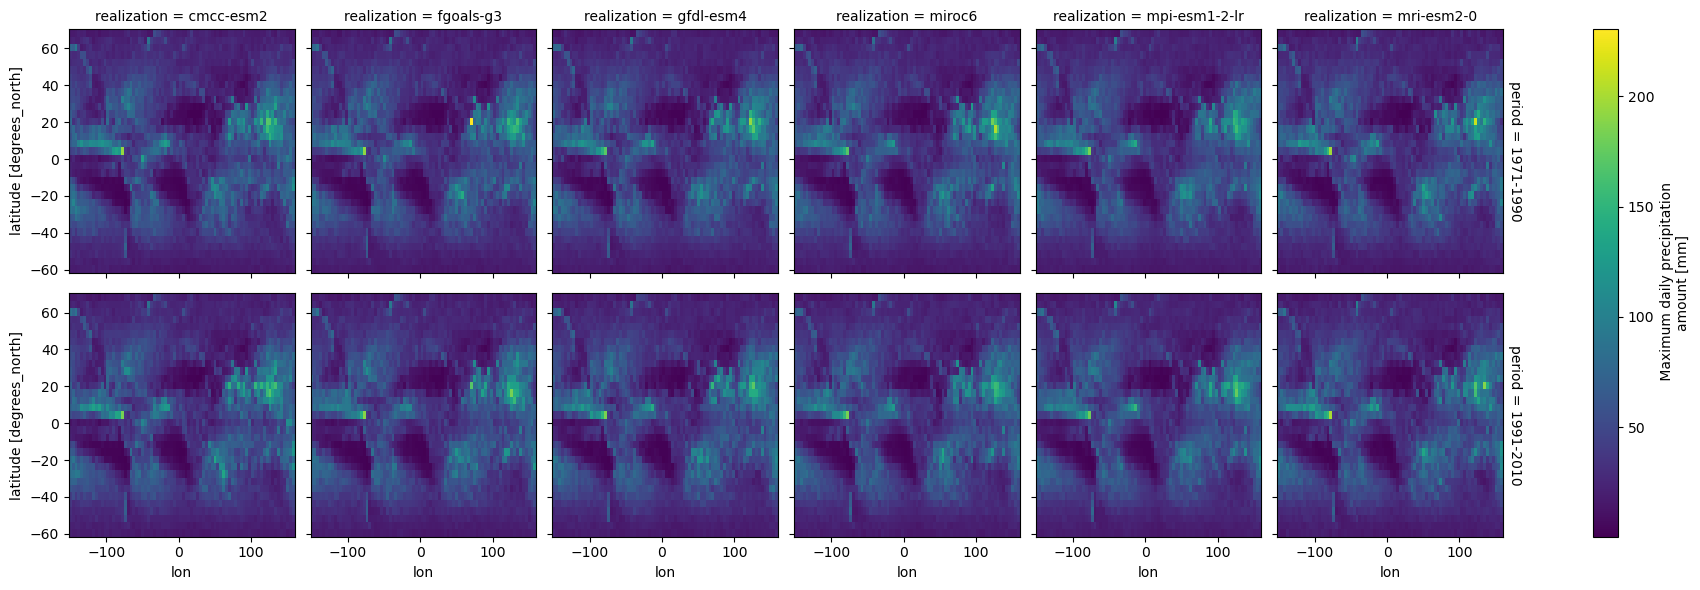

In [103]:
rx1day_fut.plot(col='realization', row = 'period')

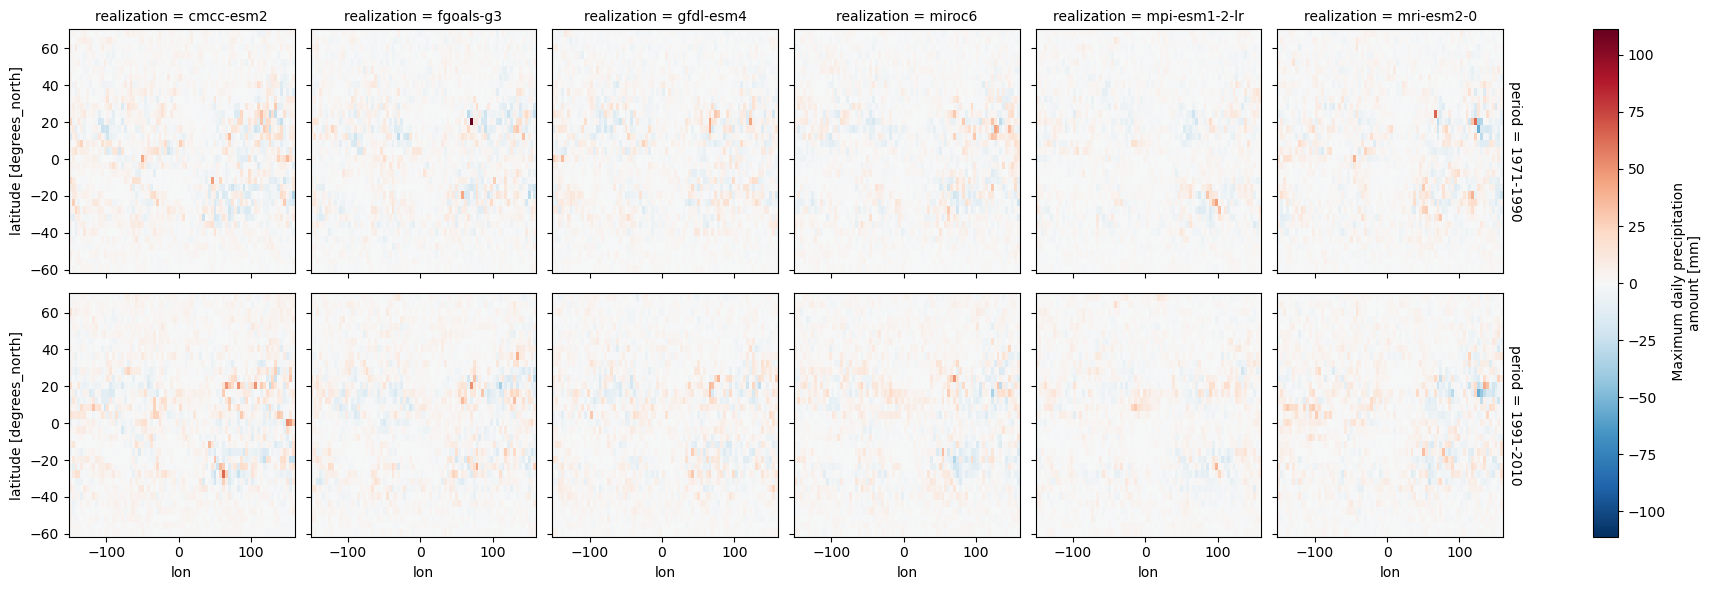

In [104]:
(rx1day_fut-rx1day_hist.isel(period=0)).plot(col='realization', row = 'period')

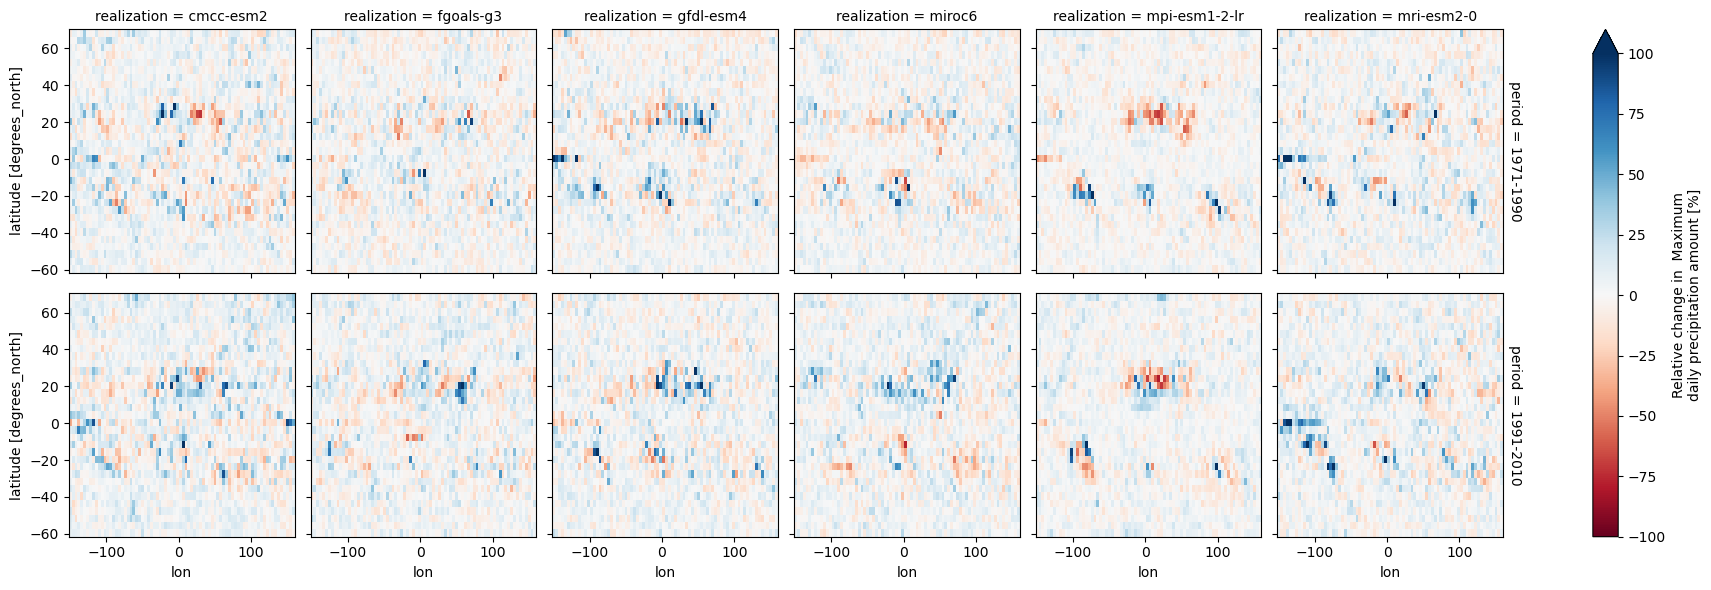

In [106]:
(rx1day_delta).plot(col='realization', row='period', vmin=-100, vmax=100, cmap='RdBu')

## RX1day_20yr

In [6]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time')
#pr_model

In [15]:
# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute RX1day using xclim indicator function
rx1day_ref, rx1day_hist, rx1day_fut, rx1day_delta = ids.compute_indicator(
    reference_data = pr_ref,
    model_data = pr_model,
    indicator_func=xclim.indices.stats.frequency_analysis, 
    mode = 'max',
    t = 20,
    method = 'ML', #'PWM',
    dist = 'gumbel_r', #'gum',
    aggregation = None,
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'rx1day_20yr',
    long_name = 'Maximum daily precipitation amount in a 20-year period',
    units = 'mm',
)


[                                        ] | 0% Completed | 299.47 us

[########################################] | 100% Completed | 1.53 ss
[########################################] | 100% Completed | 1.42 ss
[########################################] | 100% Completed | 8.18 ss
[########################################] | 100% Completed | 7.95 ss
[########################################] | 100% Completed | 8.03 ss
[########################################] | 100% Completed | 8.02 sms


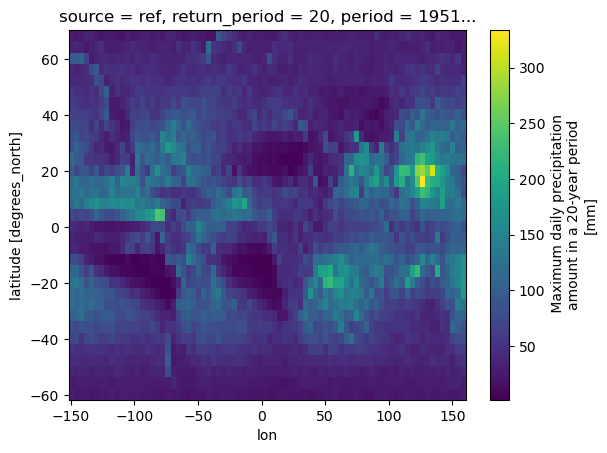

In [8]:
rx1day_ref.plot()

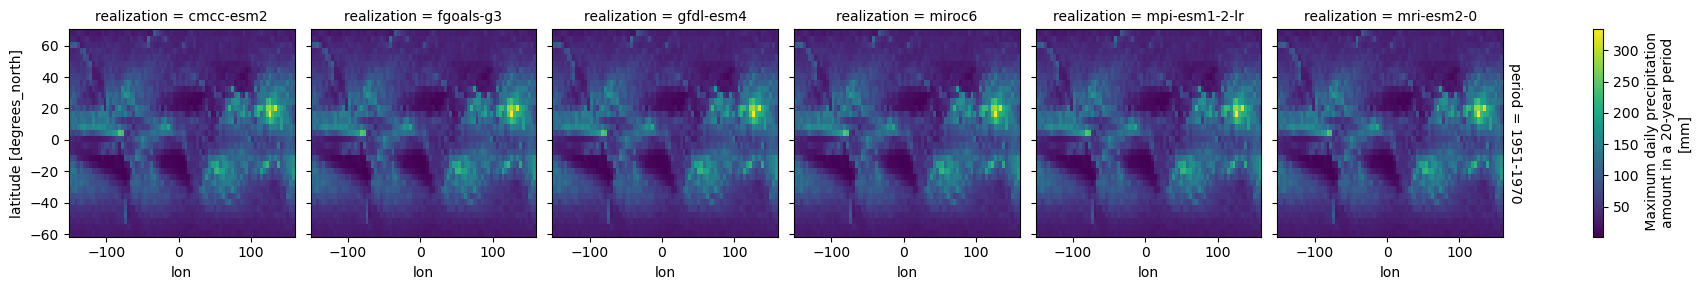

In [9]:
rx1day_hist.plot(col='realization', row='period')

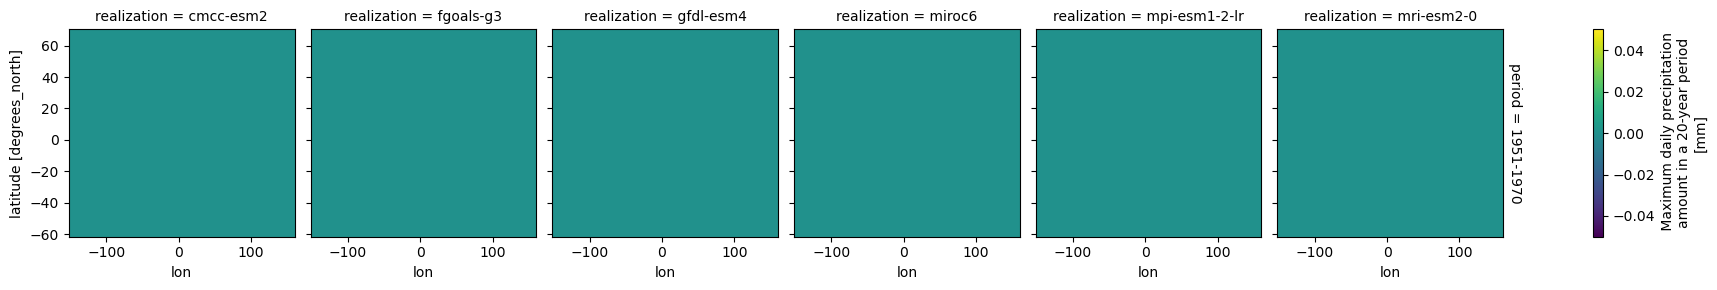

In [10]:
(rx1day_hist-rx1day_ref).plot(col='realization', row='period')

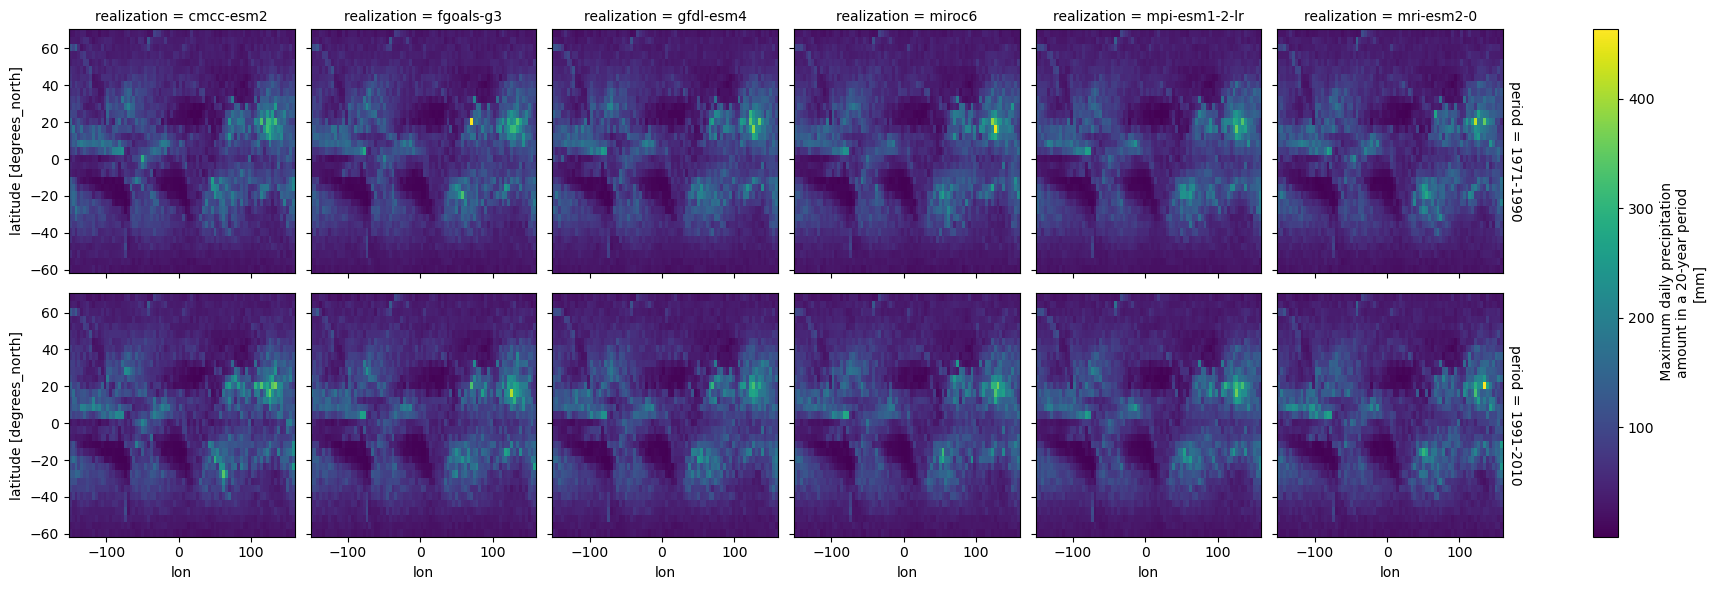

In [11]:
(rx1day_fut).plot(col='realization', row='period')

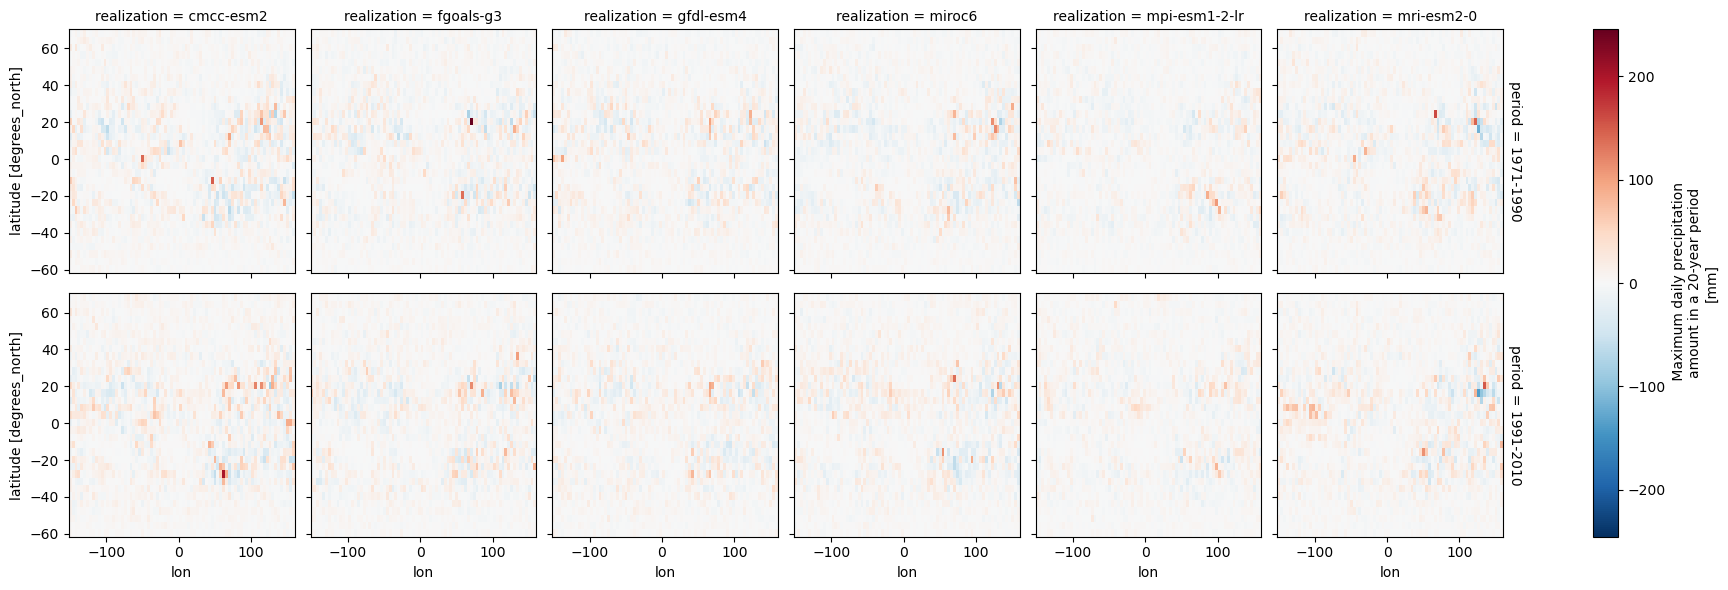

In [12]:
(rx1day_fut-rx1day_hist.isel(period=0)).plot(col='realization', row='period')

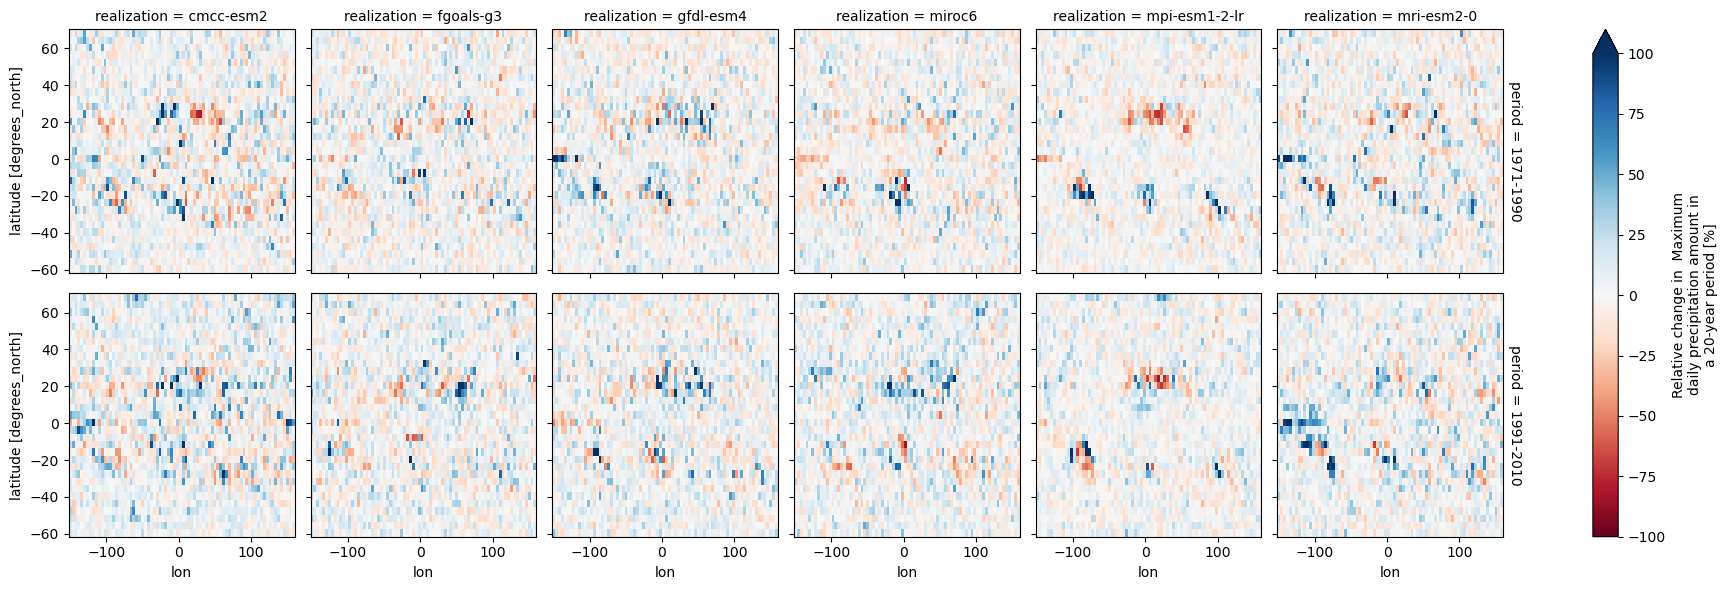

In [17]:
(rx1day_delta).plot(col='realization', row='period', vmin=-100, vmax=100, cmap='RdBu')

## TX30

In [21]:
tasmax_hist, tasmax_fut = get_refhistfut_quick('tasmax', folder = 'era5-cmip6_exp_ens',)

tasmax_ref = tasmax_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tasmax_model = xr.concat([tasmax_hist.sel(source='simu'), tasmax_fut.sel(source='simu')], dim='time')
#tasmax_model

In [22]:
# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [24]:
# Compute TX30 using xclim indicator function and corrected indicators
tx30_ref, tx30_hist, tx30_fut, tx30_delta = ids.compute_indicator(
    reference_data = tasmax_ref,
    model_data = tasmax_model,
    indicator_func=xclim.indices.tx_days_above, 
    thresh = '30 degC',
    freq = 'YS',
    delta_mode='+',
    compute = True,
    correct_threshold = True,
    short_name = 'tx30',
    long_name = 'Number of days above 30ºC',
    units = 'days'
)


[########################################] | 100% Completed | 404.12 ms
[########################################] | 100% Completed | 403.28 ms
[########################################] | 100% Completed | 2.87 ss
[########################################] | 100% Completed | 2.88 ss
[########################################] | 100% Completed | 2.47 sms
[########################################] | 100% Completed | 2.47 sms


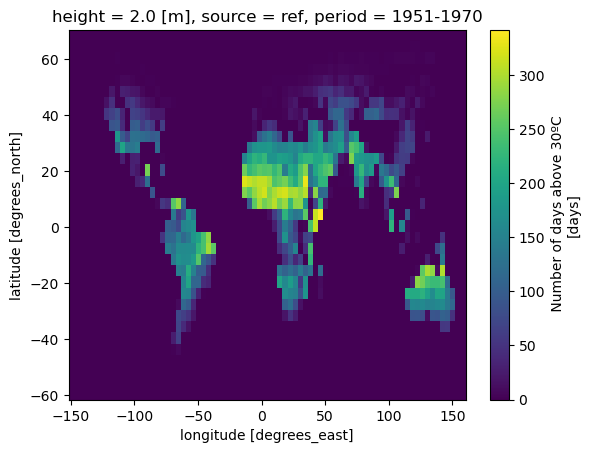

In [25]:
tx30_ref.plot()

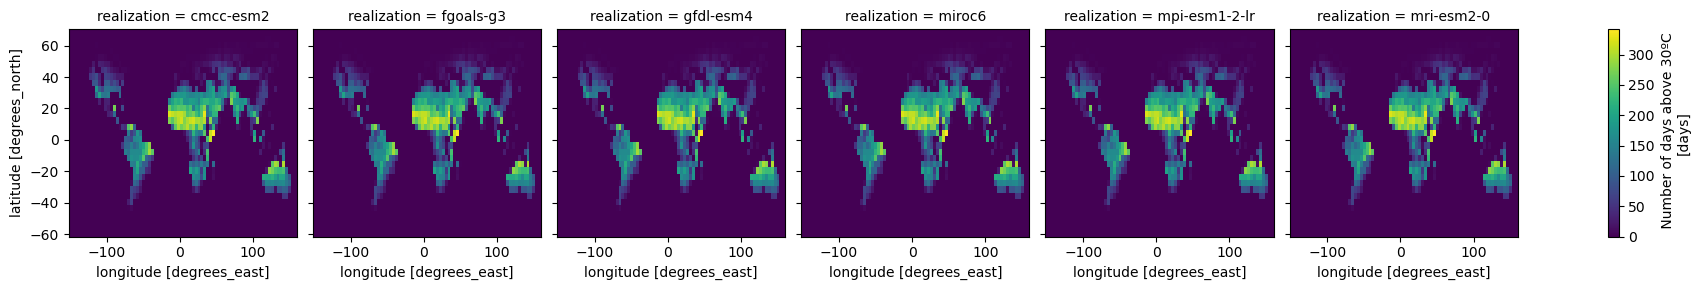

In [26]:
tx30_hist.plot(col='realization')

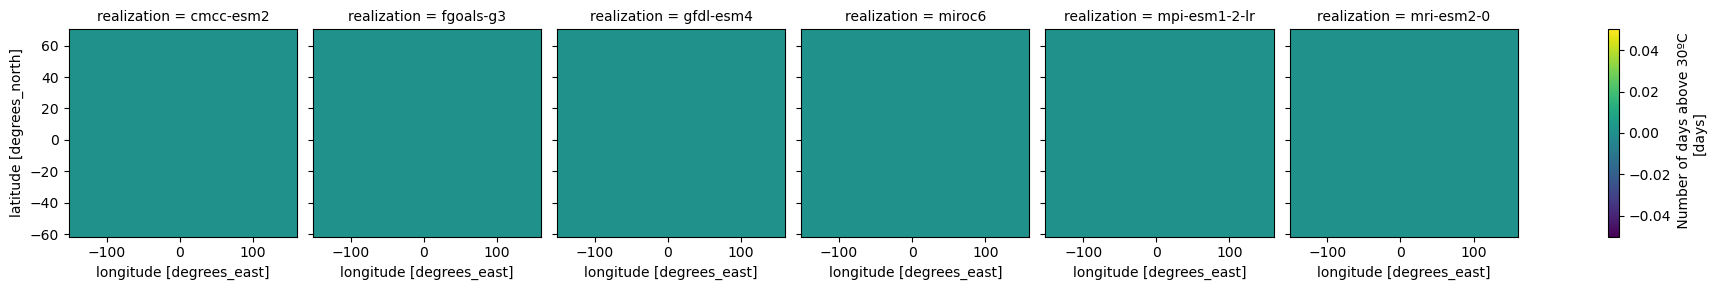

In [27]:
(tx30_hist-tx30_ref).plot(col='realization')

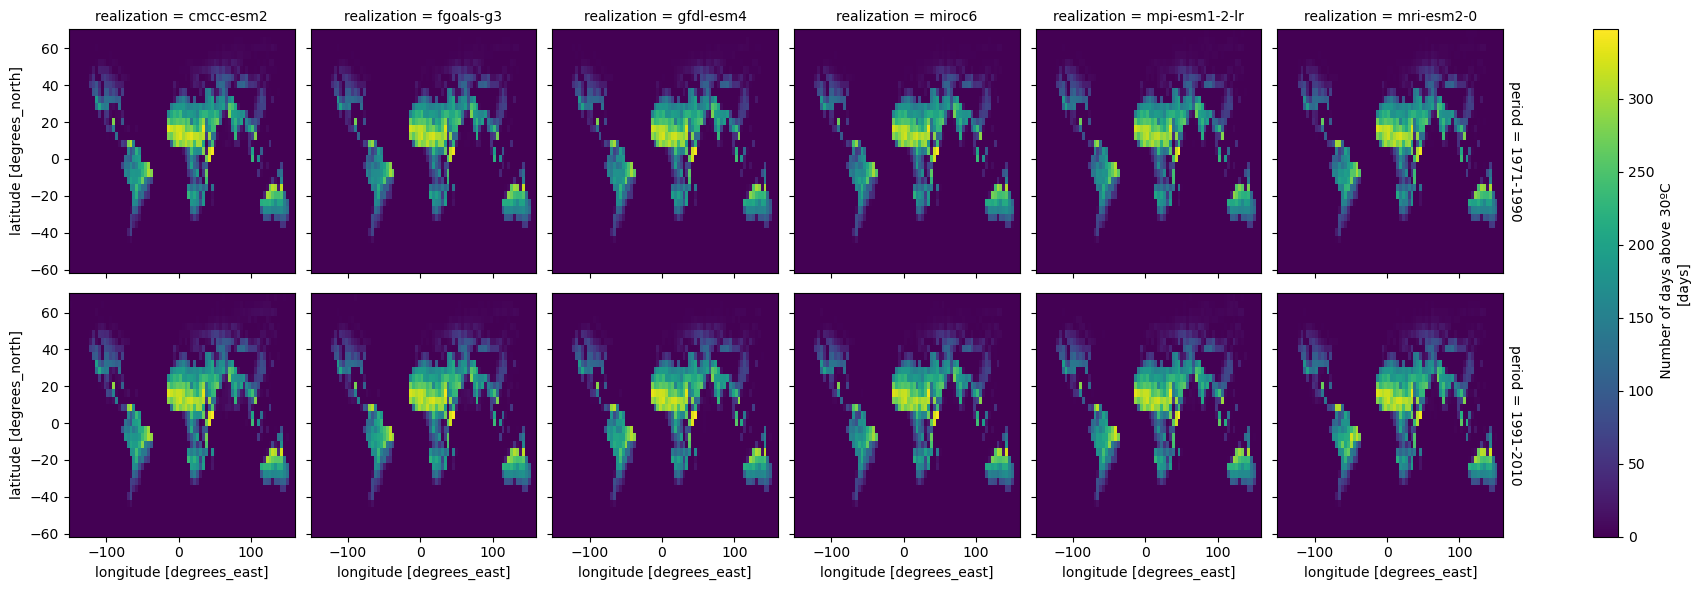

In [28]:
(tx30_fut).plot(col='realization', row='period')

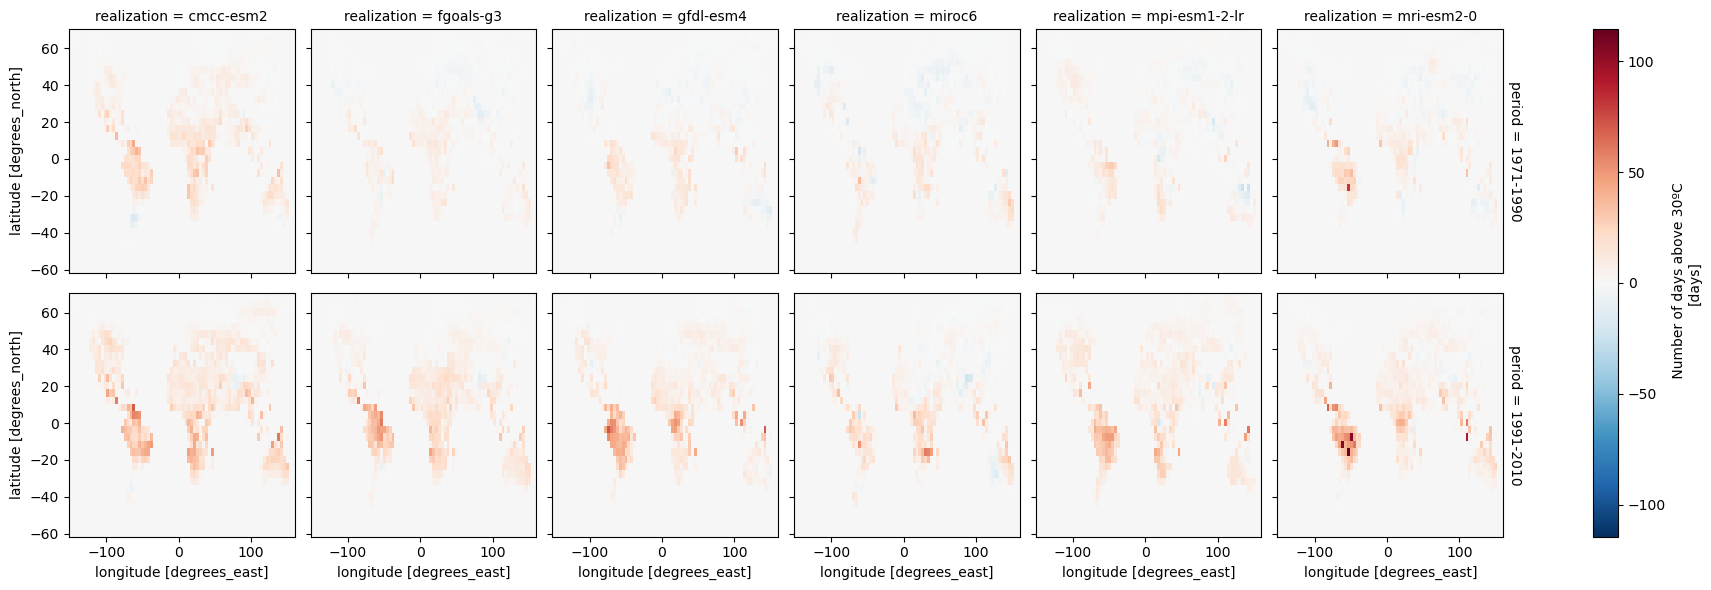

In [29]:
(tx30_fut-tx30_hist.isel(period=0)).plot(col='realization', row='period')

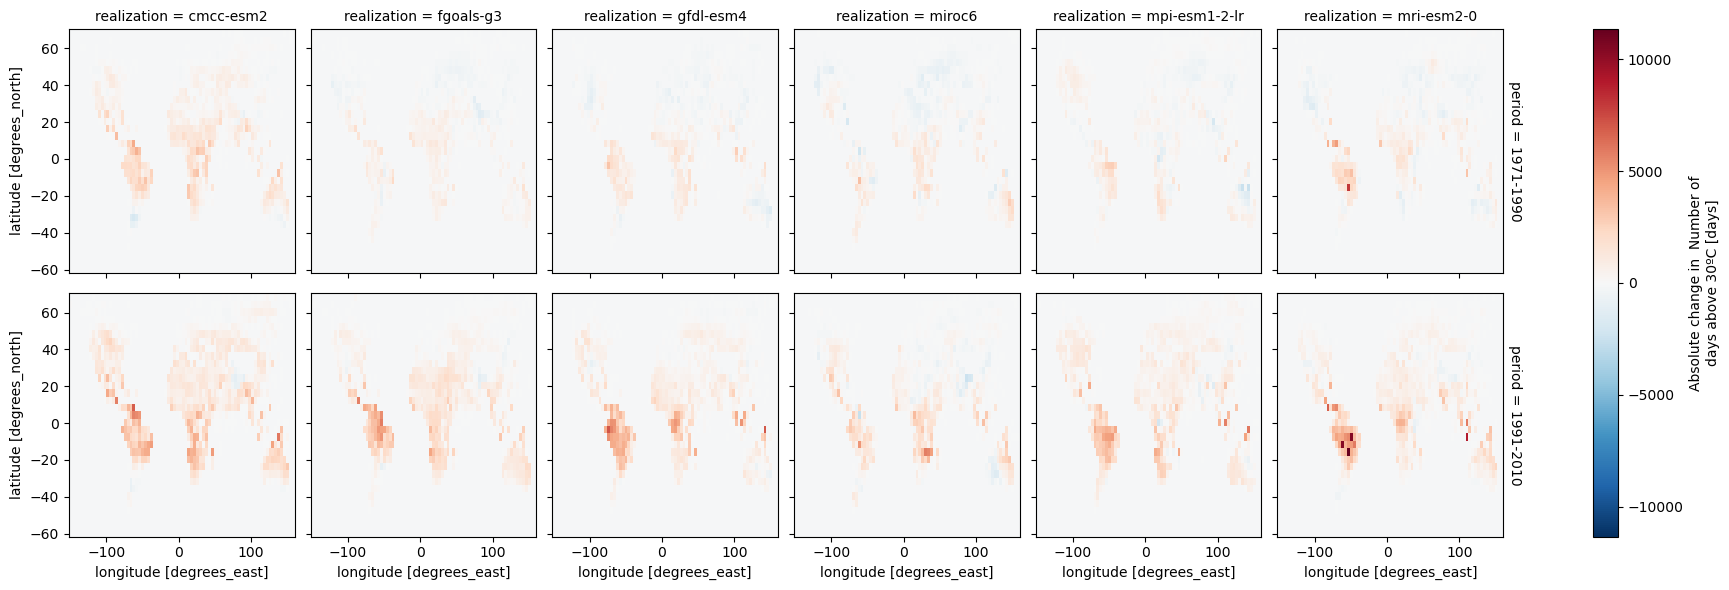

In [30]:
(tx30_delta).plot(col='realization', row='period')

## CDD

In [31]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time')
#pr_model

In [32]:
# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [33]:
# Compute CDD using xclim indicator function and corrected indicators
cdd_ref, cdd_hist, cdd_fut, cdd_delta = ids.compute_indicator(
    reference_data = pr_ref,
    model_data = pr_model,
    indicator_func=xclim.indices.maximum_consecutive_dry_days, 
    thresh = '1 mm/day',
    freq = 'YS',
    delta_mode='+',
    compute = True,
    correct_threshold = True,
    short_name = 'cdd',
    long_name = 'Maximum consecutive number of dry days',
    units = 'days'
)

[########################################] | 100% Completed | 415.49 ms
[########################################] | 100% Completed | 411.36 ms
[########################################] | 100% Completed | 3.08 ss
[########################################] | 100% Completed | 3.20 ss
[########################################] | 100% Completed | 2.98 ss
[########################################] | 100% Completed | 3.25 ss


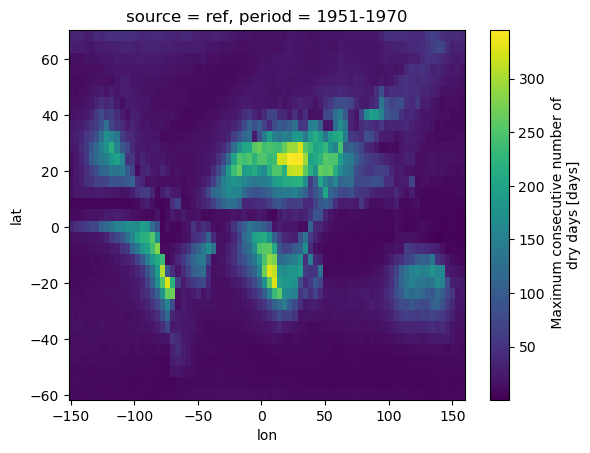

In [34]:
cdd_ref.plot()

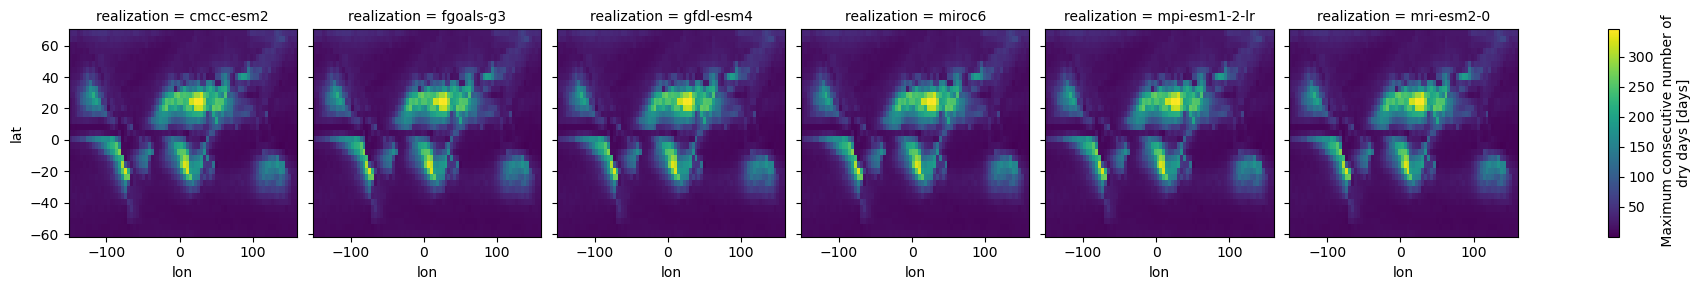

In [35]:
cdd_hist.plot(col='realization')

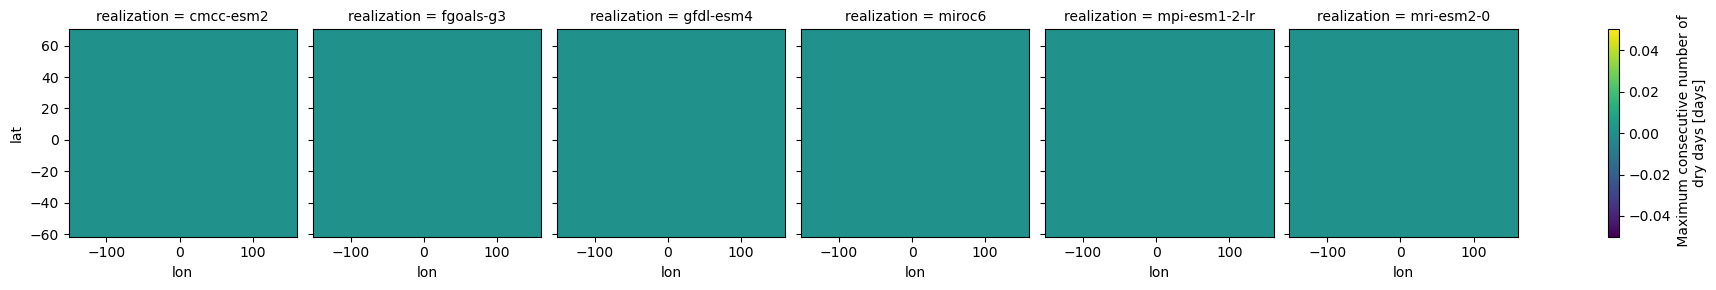

In [36]:
(cdd_hist-cdd_ref).plot(col='realization')

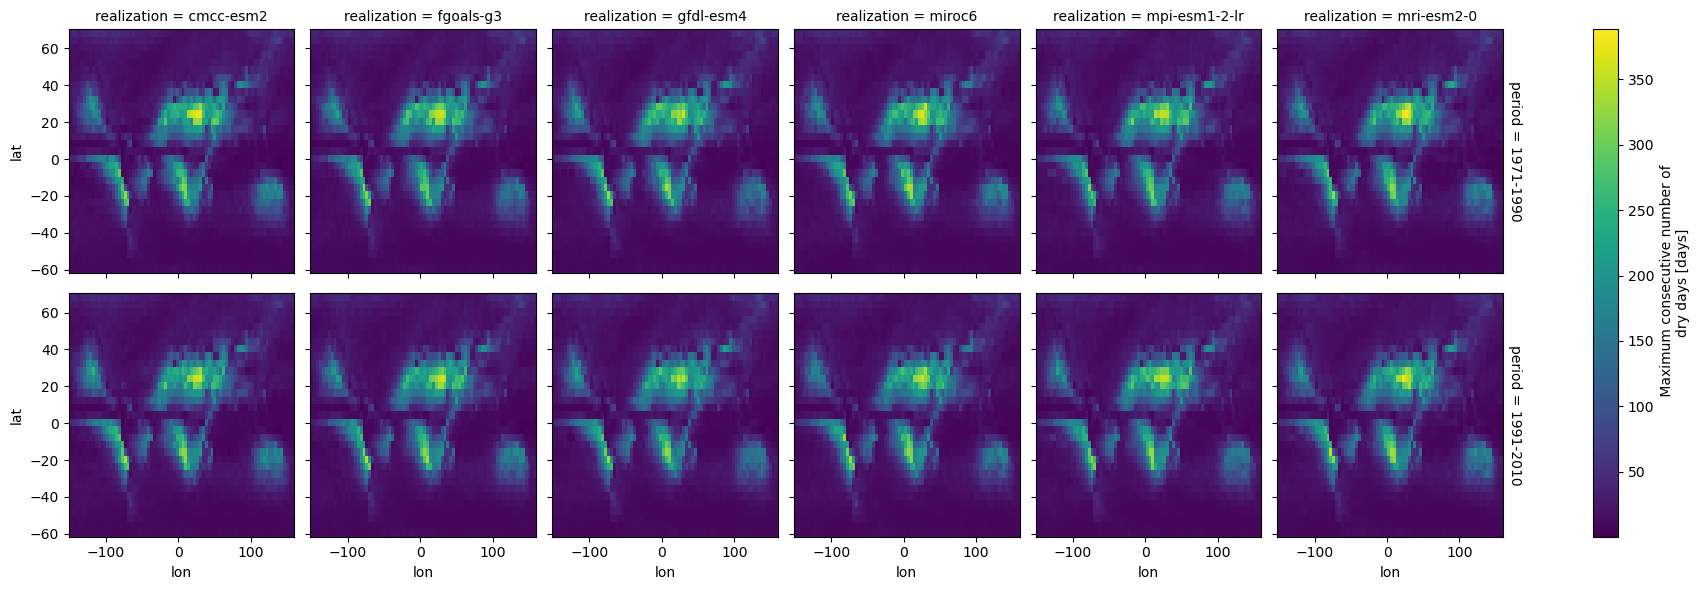

In [37]:
(cdd_fut).plot(col='realization', row='period')

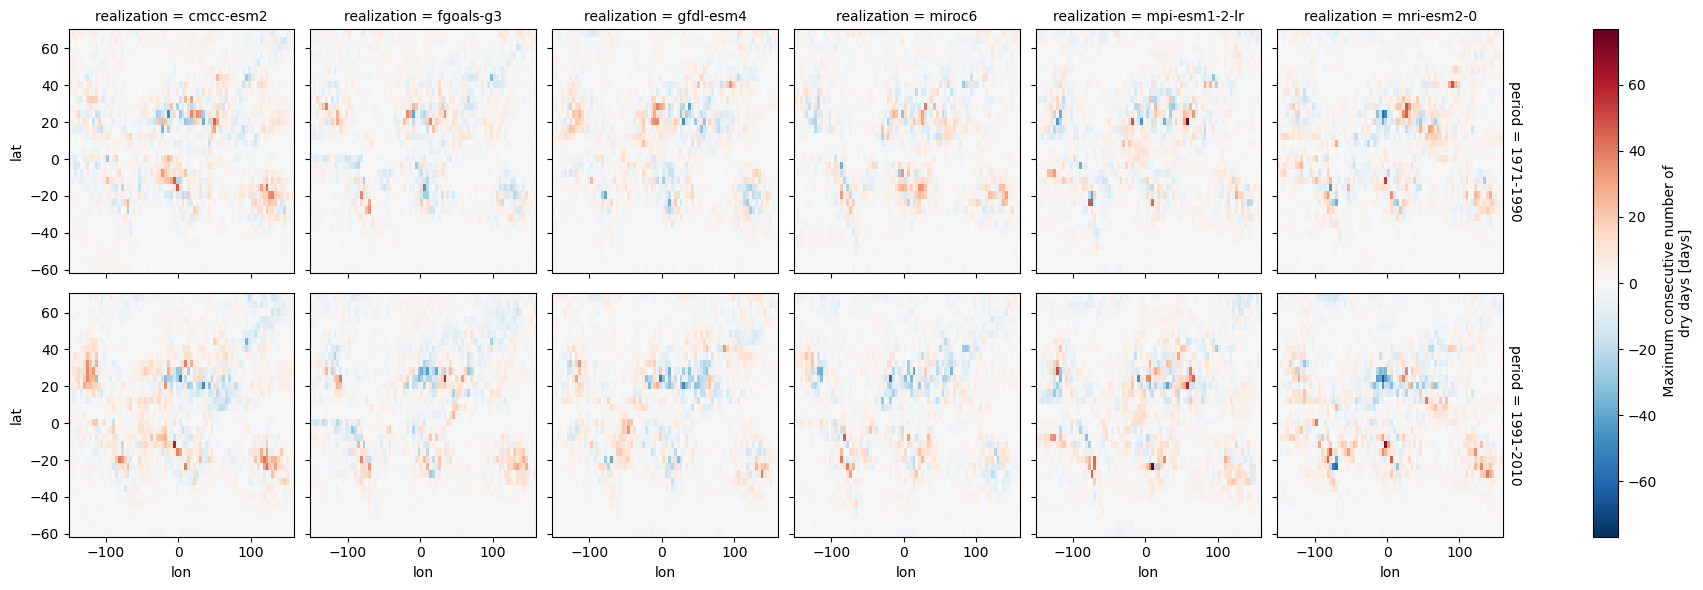

In [38]:
(cdd_fut-cdd_hist.isel(period=0)).plot(col='realization', row='period')

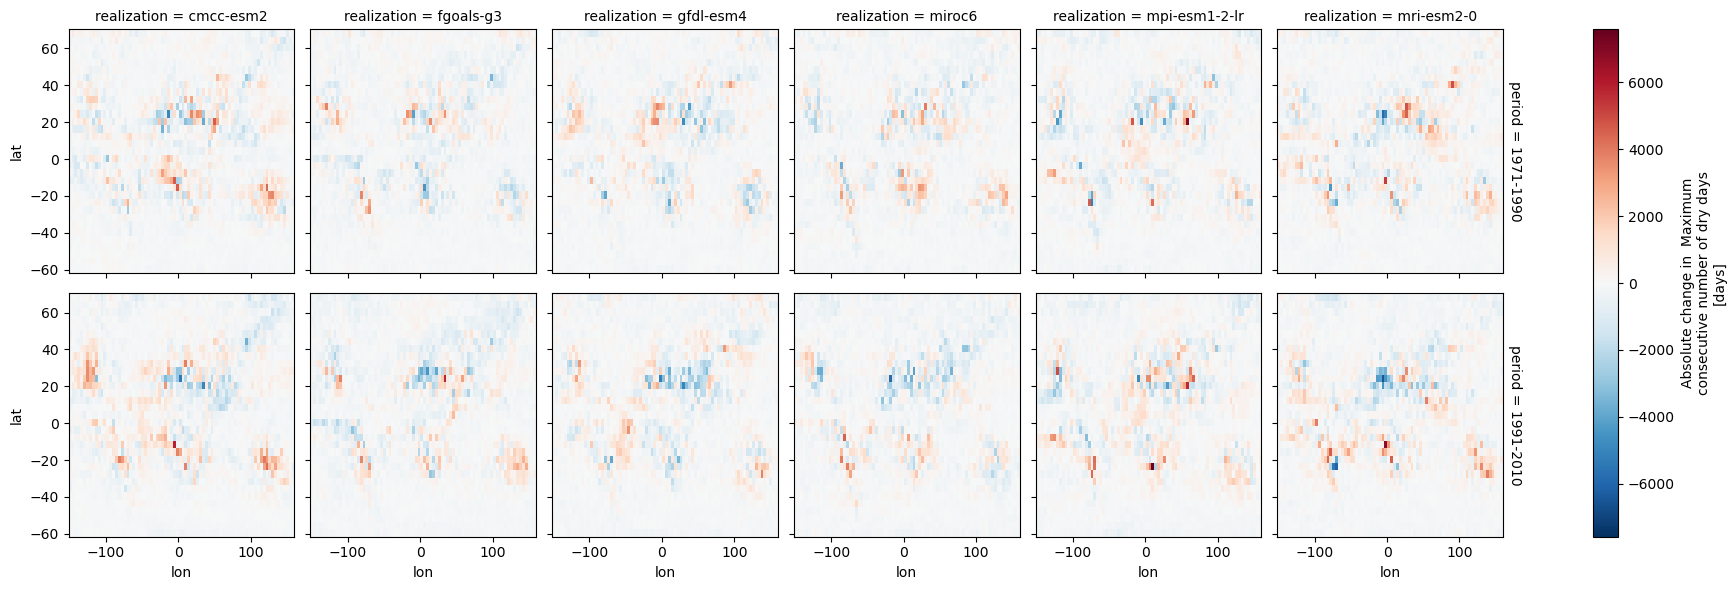

In [39]:
cdd_delta.plot(col='realization', row='period')

## WPD

In [40]:
wind_hist, wind_fut = get_refhistfut_quick('wind', folder = 'era5-cmip6_exp_ens',)

wind_ref = wind_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
wind_model = xr.concat([wind_hist.sel(source='simu'), wind_fut.sel(source='simu')], dim='time')


In [6]:
# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [51]:
from xids.indicators import get_windpowerdensity

# Compute CDD using xclim indicator function and corrected indicators
wpd_ref, wpd_hist, wpd_fut, wpd_delta = ids.compute_indicator(
    reference_data = wind_ref,
    model_data = wind_model,
    indicator_func=get_windpowerdensity, 
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'wpd',
    long_name = 'Wind Power Density',
    units = 'W/m2',
    delta_factor_limit = 5,
)

[########################################] | 100% Completed | 304.86 ms
[########################################] | 100% Completed | 202.98 ms
[########################################] | 100% Completed | 827.72 ms
For some locations, the Delta Change Factor has been limited to 5x.
[########################################] | 100% Completed | 615.53 ms
For some locations, the Delta Change Factor has been limited to 5x.
[########################################] | 100% Completed | 635.61 ms
[########################################] | 100% Completed | 621.36 ms


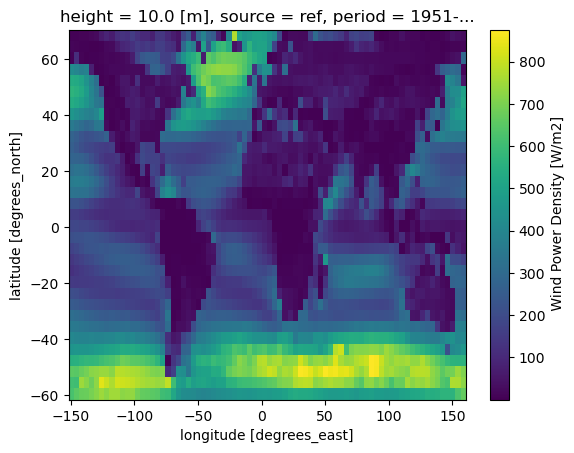

In [52]:
wpd_ref.plot()

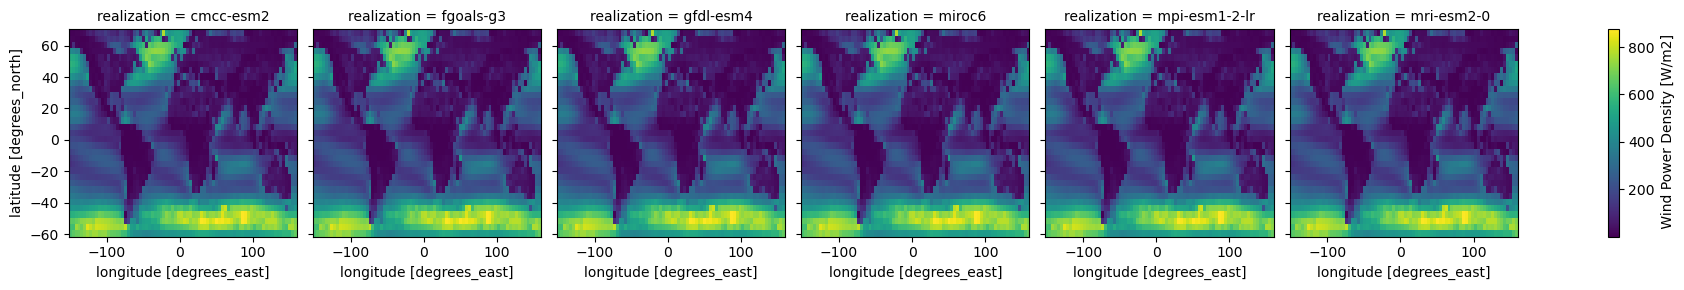

In [53]:
wpd_hist.plot(col='realization')

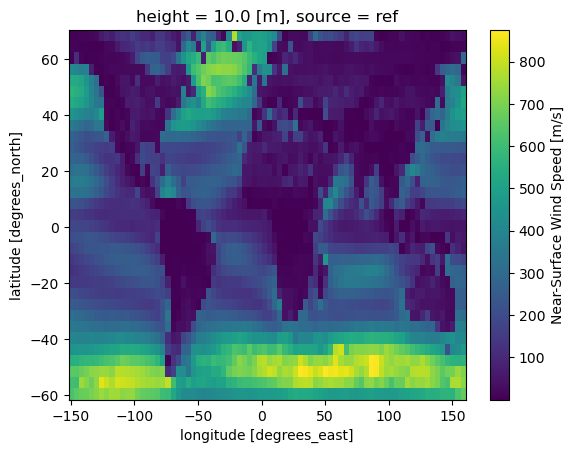

In [54]:
wpd_fut0 = get_windpowerdensity(wind_ref.sel(time=slice('1951','1970'))).mean('time')
wpd_fut0.plot()

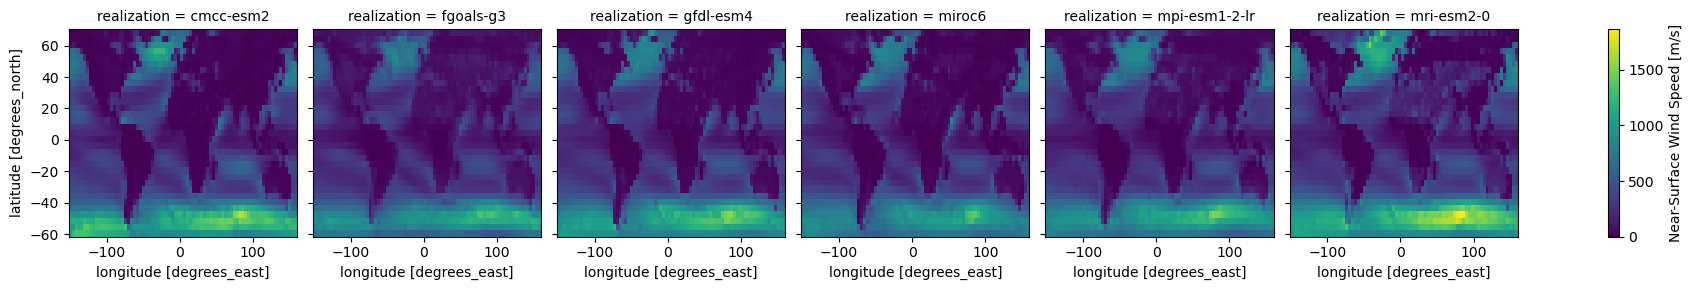

In [55]:
wpd_fut0 = get_windpowerdensity(wind_model.sel(time=slice('1951','1970'))).mean('time')
wpd_fut0.plot(col='realization',)

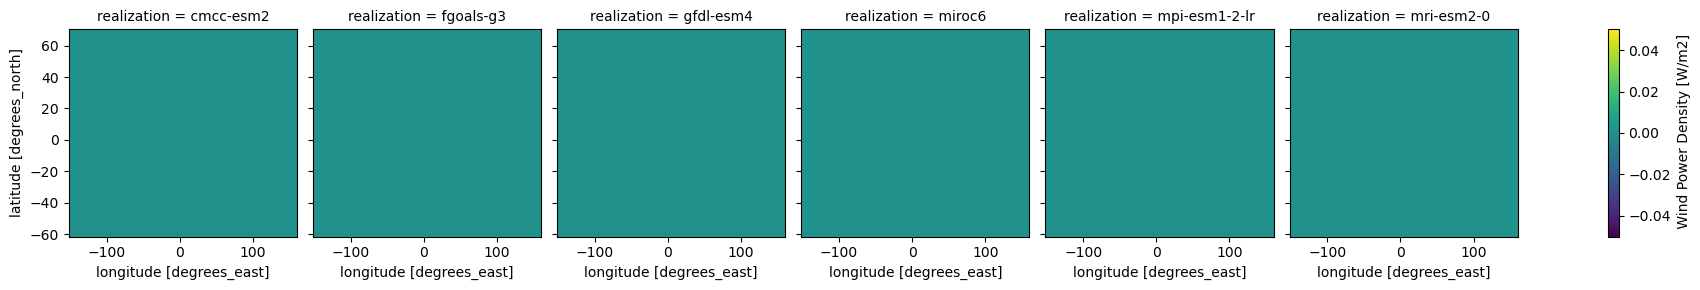

In [56]:
(wpd_hist-wpd_ref).plot(col='realization')

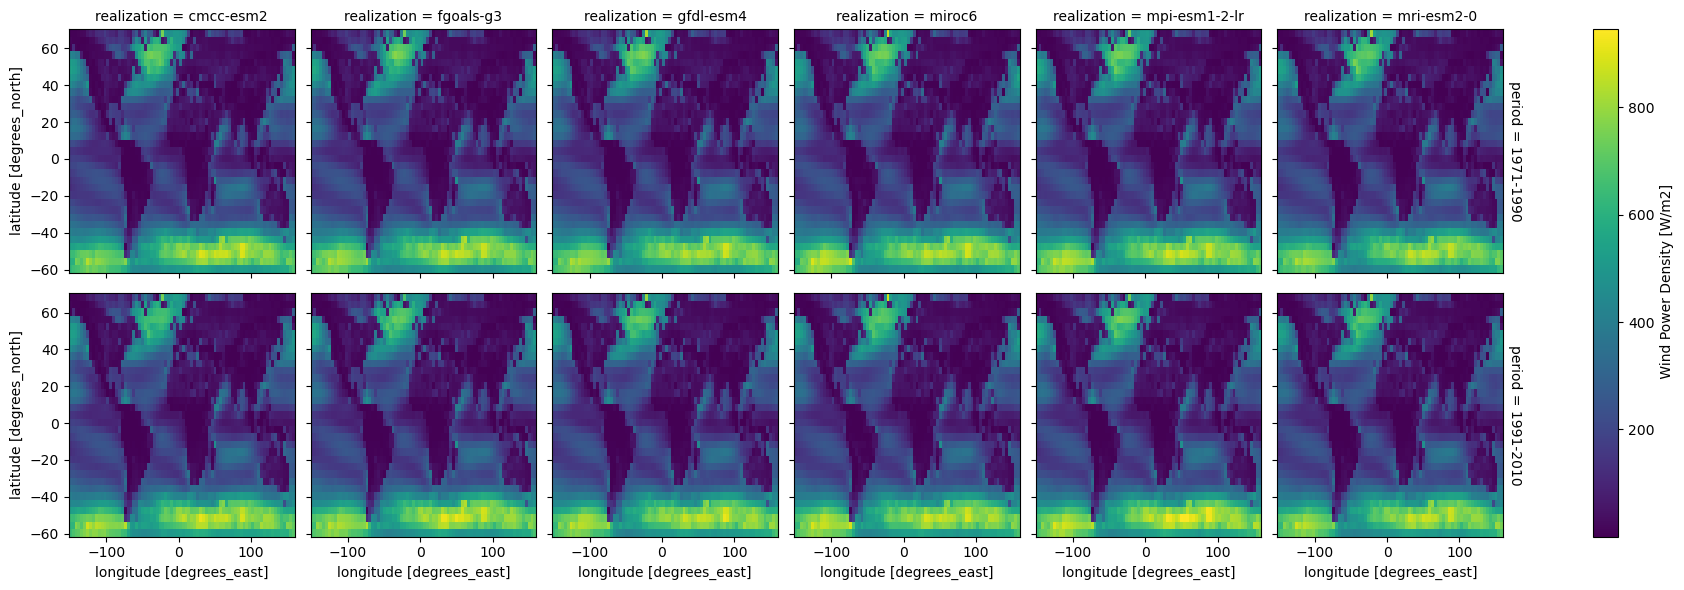

In [57]:
(wpd_fut).plot(col='realization', row='period')

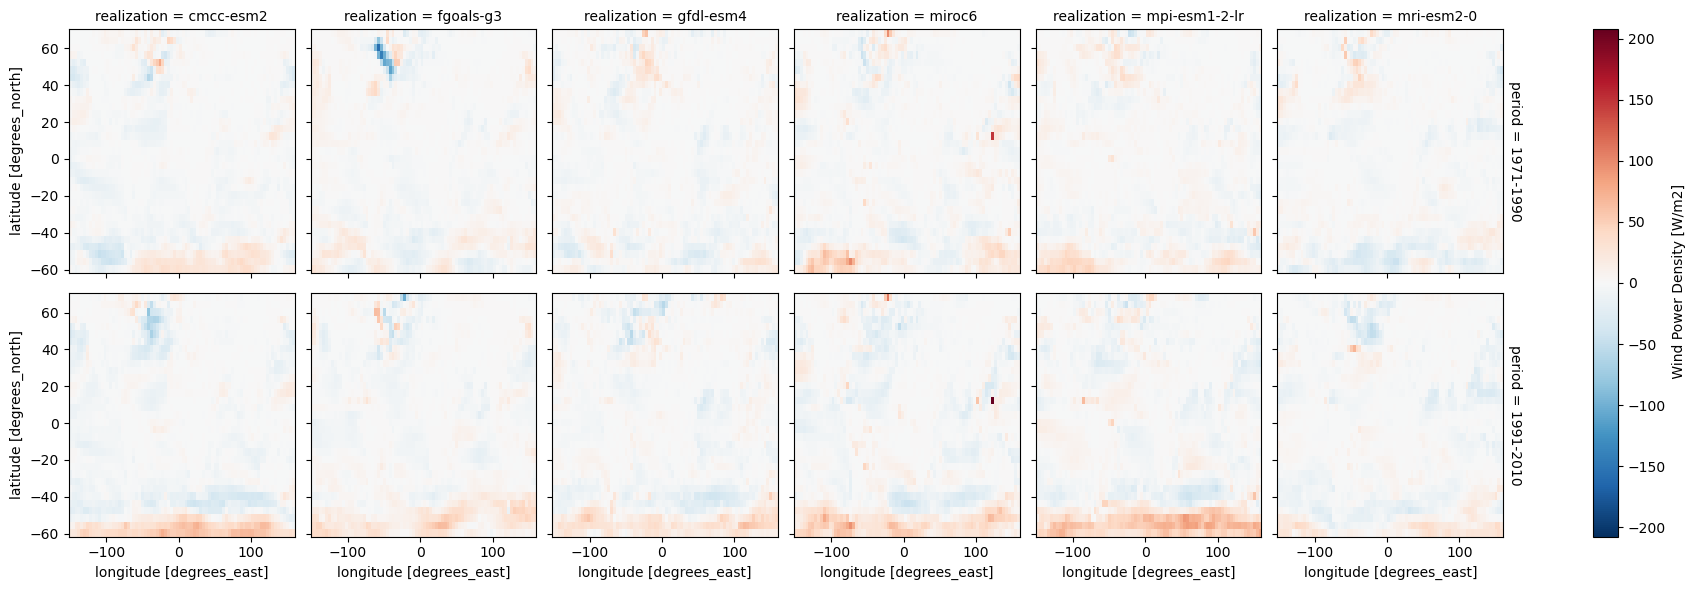

In [58]:
(wpd_fut-wpd_hist.isel(period=0)).plot(col='realization', row='period')

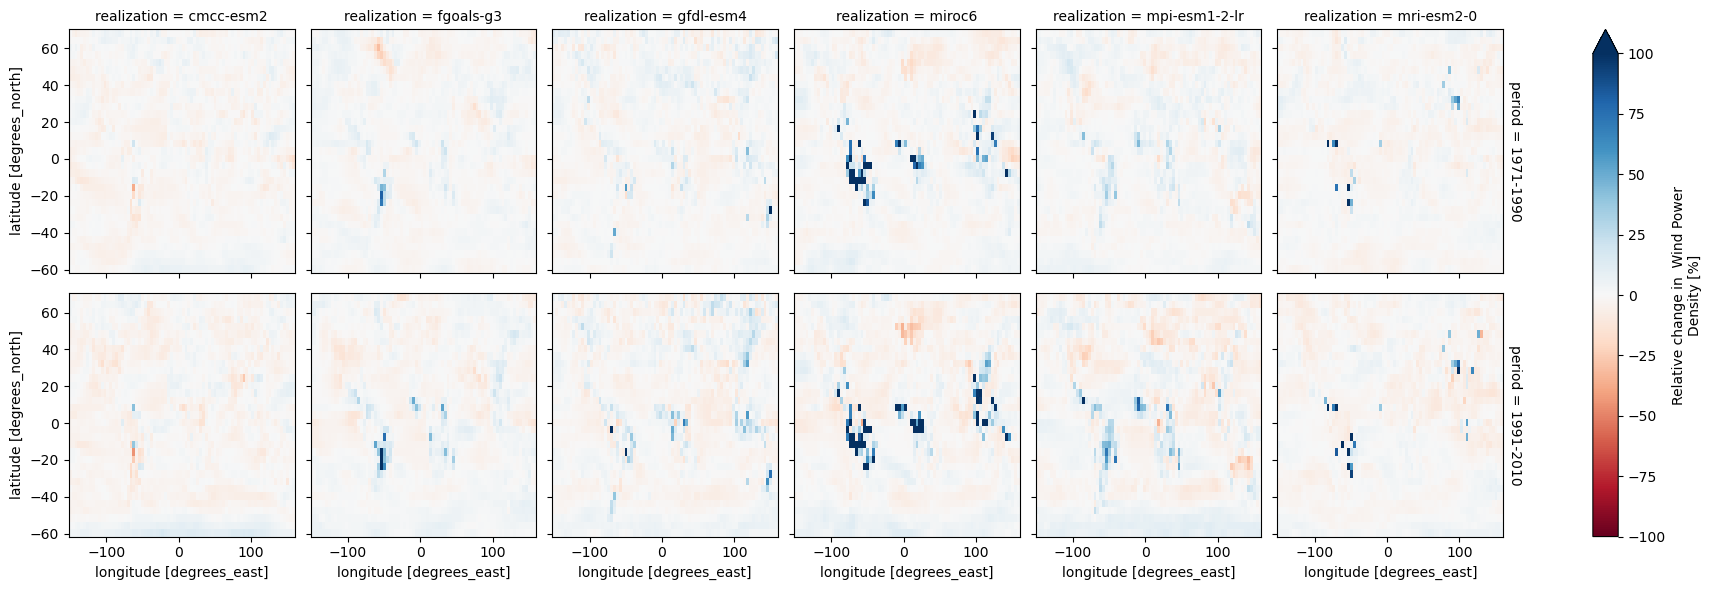

In [62]:
(wpd_delta).plot(col='realization', row='period', vmin = -100, vmax=100, cmap='RdBu')

## FWI90p

In [9]:
tas_hist, tas_fut = get_refhistfut_quick('tas', folder = 'era5-cmip6_exp_ens',)
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)
wind_hist, wind_fut = get_refhistfut_quick('wind', folder = 'era5-cmip6_exp_ens',)
hurs_hist, hurs_fut = get_refhistfut_quick('hurs', folder = 'era5-cmip6_exp_ens',)


tas_ref = tas_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tas_model = xr.concat([tas_hist.sel(source='simu'), tas_fut.sel(source='simu')], dim='time')


pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time')


wind_ref = wind_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
wind_model = xr.concat([wind_hist.sel(source='simu'), wind_fut.sel(source='simu')], dim='time')


hurs_ref = hurs_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
hurs_model = xr.concat([hurs_hist.sel(source='simu'), hurs_fut.sel(source='simu')], dim='time')


In [10]:
from xids import IDS

In [11]:
# Initialize class instance
ids = IDS(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [13]:

fwi_ref, fwi_hist, fwi_fut, fwi_delta = ids.compute_indicator(
    indicator_func=indicators.get_fwiXp,
    reference_data = (tas_ref, pr_ref, wind_ref, hurs_ref),
    model_data = (tas_model, pr_model, wind_model, hurs_model),
    lat=tas_ref.lat,
    quantile = 0.9,
    freq = 'YS',
    delta_mode='+',
    compute = True,
    short_name = 'FWIm',
    long_name = 'Average Fire Weather Index',
    units = '',
    delta_factor_limit = None,
)

AttributeError: 'tuple' object has no attribute 'chunk'